## NLP Study

### Sentiment Analysis using a word embedding and a feedforward NN

In this study we want to perform and experiment with sentiment analysis on movie review. As a first approach, we will just use a pretrained
google word2vec embedding. We will use simple regex to tokenize and we will use mean pooling to see what accuracy we get with this.

In the next step we will see how we may improve the results from the above starting point.

In [3]:
import numpy as np
import zipfile

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from keras.regularizers import l1


# 1. First we will import a pretrainted word embedidng. I dont want to train it here so we will just use a pretrained model:
from gensim.models import KeyedVectors
# Load pretrained Word2Vec binary

import kaggle
#!kaggle datasets download -d leadbest/googlenewsvectorsnegative300

# I searched for a small embedding for testing purposes. Its not word2vec but Glove instead (a different algorithm than the above)
word2vec = KeyedVectors.load_word2vec_format("GoogleNews-vectors-negative300.bin", binary=True)

In [4]:
import re

def tokenize(sentence):
    return re.findall(r"\b\w+\b", sentence.lower())


# 2. Then we will manually embed our input first via the following function
def sentence_to_vector_matrix(sentence, w2v_model, max_len=350, embedding_dim=300):
    tokens = tokenize(sentence)
    vectors = []
    for token in tokens[:max_len]:
        if token in w2v_model:
            vectors.append(w2v_model[token])
        else:
            vectors.append(np.zeros(embedding_dim))  # or random, or UNK token
    while len(vectors) < max_len:
        vectors.append(np.zeros(embedding_dim))  # pad to max_len
    return np.array(vectors)

# ... before passing it to the Neural Network that will be trained.

In [5]:
# Our Neural Network will have 3 dense layers with 64, 32, 2 layers. First one takes the embedding from above.
# Notice however that for a sentence we have a sequence of embedding vectors so we will do so called pooling
# before passing this to the model.

model = Sequential([
    Dense(512, activation='relu', input_shape=(300,)),
    Dense(256, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# we will use cross entropy loss for training later:

model.compile(optimizer='adam',
              loss='binary_crossentropy',  # or 'sparse_categorical_crossentropy' if labels are integers
              metrics=['accuracy'])

model.summary()

/home/nick/venvs/deeplib_venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-05 20:25:27.998643: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       154,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,953 (1.15 MB)

 Trainable params: 301,953 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import pandas as pd
import zipfile

# Now we need a dataset for training/testing purposes. Ill just get one from Kaggle:
!kaggle datasets download -d yasserh/imdb-movie-ratings-sentiment-analysis

with zipfile.ZipFile("imdb-movie-ratings-sentiment-analysis.zip", 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("movie.csv")

Dataset URL: https://www.kaggle.com/datasets/yasserh/imdb-movie-ratings-sentiment-analysis
License(s): CC0-1.0
imdb-movie-ratings-sentiment-analysis.zip: Skipping, found more recently modified local copy (use --force to force download)


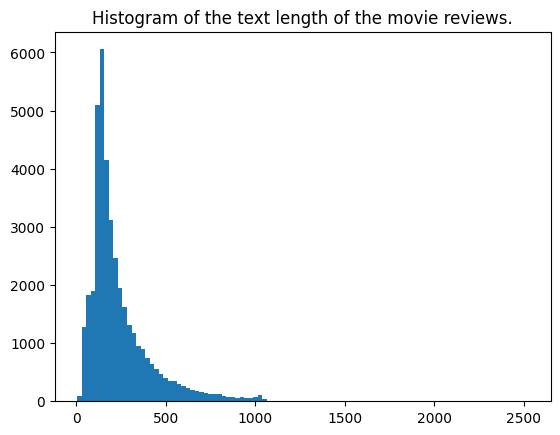

: 

In [ ]:
import matplotlib.pyplot as plt

lengths = df["text"].apply(lambda txt: len(tokenize(txt)))

plt.hist(lengths, bins=100)
plt.title("Histogram of the text length of the movie reviews.")
plt.show()

text_cutoff = int(np.quantile(lengths, 0.8)) + 1



In [ ]:
df.head()

X = df["text"].apply(lambda txt: sentence_to_vector_matrix(txt, word2vec, max_len=text_cutoff)).apply(lambda x: np.mean(x, axis=0))
X = pd.concat([X.apply(pd.Series)], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.1)


Epoch 1/10
1463/1463 [==============================] - 27s 16ms/step - loss: 0.4291 - accuracy: 0.8010 - val_loss: 0.4736 - val_accuracy: 0.7708
Epoch 2/10
1463/1463 [==============================] - 23s 16ms/step - loss: 0.3665 - accuracy: 0.8378 - val_loss: 0.4026 - val_accuracy: 0.8177
Epoch 3/10
1463/1463 [==============================] - 22s 15ms/step - loss: 0.3539 - accuracy: 0.8423 - val_loss: 0.3896 - val_accuracy: 0.8212
Epoch 4/10
1463/1463 [==============================] - 21s 15ms/step - loss: 0.3485 - accuracy: 0.8478 - val_loss: 0.4470 - val_accuracy: 0.7788
Epoch 5/10
1463/1463 [==============================] - 23s 16ms/step - loss: 0.3439 - accuracy: 0.8485 - val_loss: 0.3819 - val_accuracy: 0.8273
Epoch 6/10
1463/1463 [==============================] - 23s 16ms/step - loss: 0.3396 - accuracy: 0.8534 - val_loss: 0.3802 - val_accuracy: 0.8296
Epoch 7/10
1463/1463 [==============================] - 26s 18ms/step - loss: 0.3358 - accuracy: 0.8535 - val_loss: 0.3929 -

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

438/438 [==============================] - 3s 6ms/step - loss: 0.3573 - accuracy: 0.8490
Test accuracy: 0.8490


With this first approach we arrive at a 85% accuracy, which is not bad given the above. As a first improvement lets regard the following:

1. Instead of using the rudimentary mean pooling we could add weights to the words eg. via TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use TF-IDF to compute weights
tfidf = TfidfVectorizer(tokenizer=tokenize)
tfidf.fit(df["text"])

idf_scores = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

def sentence_to_weighted_vector(sentence, word2vec, idf_scores, dim=300):
    tokens = tokenize(sentence)
    vectors = []
    weights = []
    for token in tokens:
        if token in word2vec and token in idf_scores:
            vectors.append(word2vec[token])
            weights.append(idf_scores[token])
    if vectors:
        return np.average(vectors, axis=0, weights=weights)
    else:
        return np.zeros(dim)

C:\Users\nicks\AppData\Roaming\Python\Python310\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
X2 = df["text"].apply(lambda txt: sentence_to_weighted_vector(txt, word2vec, idf_scores)).apply(lambda x: np.mean(x, axis=0))
X2 = pd.concat([X.apply(pd.Series)], axis=1)

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.35, random_state=42)

model.fit(X2_train, y2_train, epochs=10, batch_size=16, validation_split=0.1)

Epoch 1/10
1463/1463 [==============================] - 21s 14ms/step - loss: 0.3245 - accuracy: 0.8594 - val_loss: 0.3663 - val_accuracy: 0.8377
Epoch 2/10
1463/1463 [==============================] - 95s 65ms/step - loss: 0.3236 - accuracy: 0.8597 - val_loss: 0.3605 - val_accuracy: 0.8388
Epoch 3/10
1463/1463 [==============================] - 14s 10ms/step - loss: 0.3161 - accuracy: 0.8600 - val_loss: 0.3741 - val_accuracy: 0.8273
Epoch 4/10
1463/1463 [==============================] - 18s 12ms/step - loss: 0.3180 - accuracy: 0.8604 - val_loss: 0.3589 - val_accuracy: 0.8388
Epoch 5/10
1463/1463 [==============================] - 17s 12ms/step - loss: 0.3141 - accuracy: 0.8615 - val_loss: 0.3542 - val_accuracy: 0.8442
Epoch 6/10
1463/1463 [==============================] - 14s 10ms/step - loss: 0.3111 - accuracy: 0.8629 - val_loss: 0.3815 - val_accuracy: 0.8377
Epoch 7/10
1463/1463 [==============================] - 11s 7ms/step - loss: 0.3066 - accuracy: 0.8647 - val_loss: 0.3842 - 

In [ ]:
# Evaluate on test data
test2_loss, test2_acc = model.evaluate(X2_test, y2_test)
print(f"Test accuracy: {test_acc:.4f}")

438/438 [==============================] - 0s 950us/step - loss: 0.3419 - accuracy: 0.8544
Test accuracy: 0.8490


Training shows that there is some overfitting. This is mainly due to the layer sizes I chose above (512, 256, 64). One would use a smaller NN however this was a first approach anyway so we will not bother with it.

We get the same test accuracy with this approach. One reason for this is that our embedding together with our mean pooling destroys alot of information on the sentiment of a review. Instead, we want an embedding that is much smaller and assigns a value to the word how positive or negative it is. Therefore we will get rid of the pretrained word2vec embedding above and inlcude an embedding layer into our model.

We first need to setup a tokenizer and while we are at it we will use a better text preprocessor:

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Text cleaning function
def text_preprocessing(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = ' '.join(word for word in text.split() if word not in stop_words)  # Remove stopwords
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nicks\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
preprocessed_reviews = df["text"].apply(text_preprocessing)

In [ ]:
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

# Step 1: Initialize and fit tokenizer
tokenizer = Tokenizer(lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(preprocessed_reviews)
vocab_size = len(tokenizer.word_index) + 1

# Step 2: Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(preprocessed_reviews)

# Step 3: Pad sequences to make them same length
padded_sequences = pad_sequences(sequences, padding='post', maxlen=text_cutoff)

In [ ]:
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=1, input_length=text_cutoff),
    GlobalAveragePooling1D(),  # Converts [batch, sequence, embedding] → [batch, embedding]
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 333, 1)            159543    
                                                                 
 global_average_pooling1d (  (None, 1)                 0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense_4 (Dense)             (None, 64)                128       
                                                                 
 dense_5 (Dense)             (None, 32)                2080      
                                                                 
 dense_6 (Dense)             (None, 1)                 33        
                                                                 
Total params: 161784 (631.97 KB)
Trainable params: 161784 (631.97 KB)
Non-trainable params: 0 (0.00 Byte)
______________

In [ ]:
dataset_size = y.shape[0]
train_indices = np.random.choice(range(dataset_size), int(0.35 * dataset_size), replace=False)


X3_train = padded_sequences[train_indices,:]
X3_test = padded_sequences[~np.isin(np.arange(dataset_size), train_indices), :]
y3_train = y[train_indices]
y3_test = y[~np.isin(np.arange(dataset_size), train_indices)]

model2.fit(X3_train, y3_train, epochs=10, batch_size=16, validation_split=0.1)

Epoch 1/10
788/788 [==============================] - 2s 2ms/step - loss: 0.6020 - accuracy: 0.6560 - val_loss: 0.3574 - val_accuracy: 0.8686
Epoch 2/10
788/788 [==============================] - 1s 2ms/step - loss: 0.2493 - accuracy: 0.9018 - val_loss: 0.2856 - val_accuracy: 0.8800
Epoch 3/10
788/788 [==============================] - 1s 2ms/step - loss: 0.1432 - accuracy: 0.9481 - val_loss: 0.3272 - val_accuracy: 0.8757
Epoch 4/10
788/788 [==============================] - 1s 2ms/step - loss: 0.0859 - accuracy: 0.9697 - val_loss: 0.3586 - val_accuracy: 0.8793
Epoch 5/10
788/788 [==============================] - 1s 1ms/step - loss: 0.0492 - accuracy: 0.9844 - val_loss: 0.3736 - val_accuracy: 0.8836
Epoch 6/10
788/788 [==============================] - 1s 1ms/step - loss: 0.0268 - accuracy: 0.9924 - val_loss: 0.4262 - val_accuracy: 0.8857
Epoch 7/10
788/788 [==============================] - 1s 1ms/step - loss: 0.0184 - accuracy: 0.9944 - val_loss: 0.4806 - val_accuracy: 0.8793
Epoch 

In [ ]:
# Evaluate on test data
test3_loss, test3_acc = model2.evaluate(X3_test, y3_test)
print(f"Test accuracy: {test3_acc:.4f}")

813/813 [==============================] - 1s 615us/step - loss: 0.6689 - accuracy: 0.8768
Test accuracy: 0.8768


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y3_test, (model2.predict(X3_test) >= 0.5).astype(int).T[0]))



813/813 [==============================] - 0s 536us/step
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     13040
           1       0.90      0.85      0.87     12960

    accuracy                           0.88     26000
   macro avg       0.88      0.88      0.88     26000
weighted avg       0.88      0.88      0.88     26000



We got a little bit better but still not >90% accuracy. The reason is that the mean pooling is just to rudimentary. For instance the word order is lost. This model doesnt try to understand language but rather fish for positive or negative words in the review. This is exactly what naive bayes would also do. Below we compare the accuracy to a multinomial naive bayes model which scores similar accuracy.

In [ ]:
# Get the embedding layer
embedding_layer = model2.layers[0]

# Get the embedding weights
embedding_weights = embedding_layer.get_weights()[0]

index_word = {word: embedding_weights.T[0][idx] for word, idx in tokenizer.word_index.items()}
sorted(list(index_word.items()), key=lambda x: -x[1])[:10] + sorted(list(index_word.items()), key=lambda x: x[1])[:10]

[('awful', 1.2368932),
 ('waste', 1.1288906),
 ('410', 0.8563648),
 ('worst', 0.8391821),
 ('disappointment', 0.83791864),
 ('310', 0.81996477),
 ('forgettable', 0.8000638),
 ('save', 0.79100996),
 ('110', 0.76079154),
 ('sucks', 0.76035887),
 ('710', -1.0095816),
 ('810', -0.9620475),
 ('1010', -0.7660913),
 ('superb', -0.7446171),
 ('wonderfully', -0.7386271),
 ('gem', -0.72574717),
 ('refreshing', -0.725373),
 ('excellent', -0.70660627),
 ('fantastic', -0.7037109),
 ('perfectly', -0.6719744)]

We see that the words with the highest weights coresspond to positive adjectives and something like 910 which is "9/10" in the review while negative adjectives dominate the words with the lowest weights together with something like "2/10". Lets have a look at reviews that are wrongly predicted:

In [ ]:
test_indices = pd.Series([i for i in range(dataset_size) if i not in train_indices])
misclassified_indices = y3_test[y3_test != (model2.predict(X3_test) >= 0.5).astype(int).T[0]].index

df["text"].iloc[misclassified_indices].tolist()[3]

813/813 [==============================] - 0s 523us/step


'First, I should mention that I really enjoyed ISHII Katsuhito\'s previous film "Samehada Otoko to Momojiri Onna" ("Shark Skin Man and Peach Hip Girl"). Although it owed a debt to Tarentino\'s "Pulp Fiction", Ishii\'s cast was up to the task of carrying the story, and the entire film crackled with energy. The scenes between ASANO Tadanobu and GASHUIN Tatsuya were particularly engaging. There was action, intrigue, bizarre characterizations, enough sex to keep things interesting, and an utterly unpredictable story line.<br /><br />So it was with a certain amount of anticipation and optimism that I began to watch "Party 7". And my enthusiasm was certainly piqued with the opening credits, which left my wife and I actually stunned by how dynamic and exciting they were; the mix of anime and live-action work was brilliant! Then, the actual movie started. Actually, it didn\'t so much "start" as sort of shuffle in the side door and stand there, fumbling through its pockets, looking uncomfortabl

Since this
Before heading to more sophisticated methods, lets for the sake of curiosity compare this to a naive bayes model...

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
wordcounts = vectorizer.fit_transform(df["text"].apply(text_preprocessing))

X4_train, X4_test, y4_train, y4_test = train_test_split(wordcounts, y, test_size=0.35, random_state=42)

clf = MultinomialNB()
clf.fit(X4_train, y4_train)
y4_predict = clf.predict(X4_test)
print(classification_report(y4_test, y4_predict))


              precision    recall  f1-score   support

           0       0.84      0.88      0.86      6925
           1       0.88      0.84      0.86      7075

    accuracy                           0.86     14000
   macro avg       0.86      0.86      0.86     14000
weighted avg       0.86      0.86      0.86     14000



### A more sophisticaed approach using RNNs

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

model3 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=50, input_length=text_cutoff),
    SimpleRNN(units=256),
    Dense(256, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam',
              loss='binary_crossentropy',  # or 'sparse_categorical_crossentropy' if labels are integers
              metrics=['accuracy'])

model3.summary()

Model: "sequential_34"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_32 (Embedding)    (None, 333, 50)           7977150   
                                                                 
 simple_rnn_23 (SimpleRNN)   (None, 256)               78592     
                                                                 
 dense_90 (Dense)            (None, 256)               65792     
                                                                 
 dense_91 (Dense)            (None, 32)                8224      
                                                                 
 dense_92 (Dense)            (None, 1)                 33        
                                                                 
Total params: 8129791 (31.01 MB)
Trainable params: 8129791 (31.01 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
#model3.fit(X3_train, y3_train, epochs=10, batch_size=16, validation_split=0.1)

word2vec

In [ ]:
# Evaluate on test data
test3_loss, test3_acc = model3.evaluate(X3_test, y3_test)
print(f"Test accuracy: {test3_acc:.4f}")